In [2]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

In [3]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description = "What to cover")

In [4]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [19]:
class State(TypedDict):
    topic: str
    plan: Plan
    # reducer: results from workers get concatenated automatically
    sections: Annotated[list[str], operator.add]
    final: str

In [20]:
llm = ChatOpenAI(model = "gpt-4.1-mini")

In [21]:
def orchestrator(state: State) -> dict:
    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content = (
                    "Create a blog plan with 5-7 sections on the following topic."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    return {"plan": plan}

In [22]:
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks]

In [23]:
def worker(payload: dict) -> dict:

    # payload contains what we sent
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content = (
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    f"Return only the section content in Markdown."
                )
            )
        ]
    ).content.strip()

    return {"sections": [section_md]}


In [ ]:
from pathlib import Path

def reducer(state: State) -> dict:
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # ----------- save to file ------------------
    filename = title.lower().replace(" ", "_") +".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

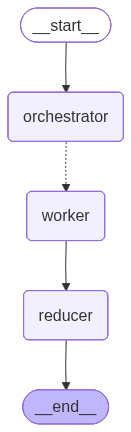

In [33]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()
app

In [34]:
out = app.invoke({"topic": "Write a blog on Self Attention", "sections": []})

**** ['## Introduction to Self-Attention\n\nSelf-attention is a powerful mechanism in deep learning that allows models to weigh the importance of different parts of an input sequence when processing data. Unlike traditional methods that process words or tokens sequentially, self-attention enables a model to consider the entire sequence simultaneously, dynamically adjusting the focus to relevant elements at each step.\n\nIn the context of natural language processing (NLP), self-attention plays a critical role by helping models understand the relationships between words regardless of their position in a sentence. For example, in the sentence *"The cat that chased the mouse was hungry,"* self-attention allows the model to associate *"cat"* with *"was hungry"* even though they are separated by several words.\n\nThis capability has made self-attention the backbone of many state-of-the-art NLP architectures, especially Transformer models. By capturing long-range dependencies efficiently and 

In [35]:
out

{'topic': 'Write a blog on Self Attention',
 'plan': Plan(blog_title='Understanding Self-Attention: The Backbone of Modern NLP', tasks=[Task(id=1, title='Introduction to Self-Attention', brief='Explain what self-attention is and why it is important in natural language processing and deep learning.'), Task(id=2, title='How Self-Attention Works', brief='Describe the mechanics of self-attention, including queries, keys, and values, and how attention scores are calculated.'), Task(id=3, title='Self-Attention vs. Traditional Attention Mechanisms', brief='Compare self-attention with classical attention mechanisms to highlight the unique benefits.'), Task(id=4, title='Applications of Self-Attention in Models', brief='Discuss how self-attention is utilized in popular models like Transformer, BERT, and GPT.'), Task(id=5, title='Advantages of Self-Attention', brief='Detail the strengths of self-attention such as parallelization, capturing long-range dependencies, and scalability.'), Task(id=6, t